In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# 2D example 
word_embeddings = {
    "cat": [0.8, 0.6],
    "kitten": [0.75, 0.65],
    "dog": [0.7, 0.3],
    "puppy": [0.65, 0.35],
    "car": [-.05, 0.2],
    "truck": [-.045, 0.15]
}

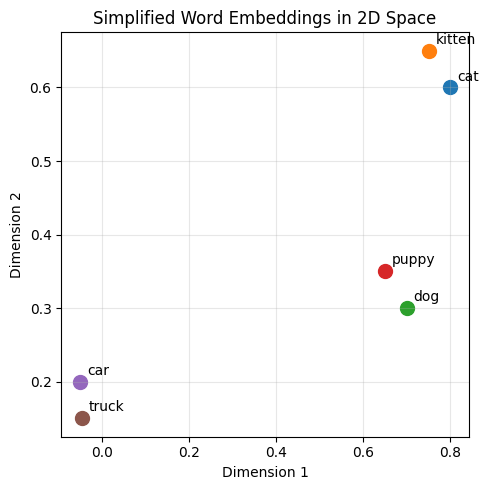

In [5]:
fig, ax = plt.subplots(figsize=(5,5))

for word, coords in word_embeddings.items():
    ax.scatter(coords[0], coords[1], s=100)
    ax.annotate(word, (coords[0], coords[1]), xytext=(5,5),
    textcoords='offset points')

ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('Simplified Word Embeddings in 2D Space')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Measuring Similarity

In [6]:
def cosine_similarity(vec1, vec2):
    """
    Cosine Similarity measutes
    - Result close to 1: very similar
    - Result close to 0: not related
    - Result close to -1: opposite meaning
    """

    dot_product = np.dot(vec1, vec2)
    norm_a = np.linalg.norm(vec1)
    norm_b = np.linalg.norm(vec2)
    return dot_product/(norm_a * norm_b)

In [7]:
cat = [0.8, 0.6]
kitten = [0.75, 0.65]
dog = [0.7, 0.3]
puppy = [0.65, 0.35]
car = [-.05, 0.2]
truck = [-.045, 0.15]

cat_kitten_similarity = cosine_similarity(cat, kitten)
print(cat_kitten_similarity)
cat_kitten_similarity

0.9975095892825593


np.float64(0.9975095892825593)

# Creating First Embeddings

In [ ]:
### Huggingface and OpenAI Models

from langchain_huggingface import HuggingFaceEmbeddings

## Initialize a simple Embedding model (no API Key needed!)
embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    # model_name="sentence-transformers/paraphrase-multilingual-MinLM-L12-v2",
    multi_process=True,
    show_progress=True,
    cache_folder="./model_cache/"
    # model_kwargs = {"device": "gpu"}
)
embedding_model

d:\Learning\RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2413.20it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder='./model_cache/', model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=True, show_progress=True)

In [9]:
## create first embeddings

text = "Hello I am learning aboutEmbedding."

embedding = embedding_model.embed_query(text)
print(f"Text: {text}")
print(f"Embedding Length: {len(embedding)}")

print(embedding)

Text: Hello I am learning aboutEmbedding.
Embedding Length: 384
[0.02757287211716175, -0.05961420014500618, -0.022028211504220963, -0.011055931448936462, -0.015385875478386879, 0.05664937198162079, 0.015865076333284378, 0.02977033704519272, 0.007026189938187599, 0.02378438413143158, 0.01708821952342987, 0.04991064593195915, 0.05235565826296806, 0.010263300500810146, -0.05777532979846001, -0.03004179522395134, 0.07085824757814407, 0.019740471616387367, -0.0925258994102478, 0.006234645843505859, -0.012248769402503967, -0.03039318323135376, -0.016171075403690338, -0.08059456199407578, 0.010008946992456913, 0.006592261139303446, -0.021327156573534012, -0.0031526198145002127, 0.1808418184518814, -0.05430714413523674, 0.01865367963910103, 0.0358889140188694, 0.011547290720045567, 0.03665526956319809, -0.06267263740301132, 0.1107170358300209, 0.02916751801967621, -0.0022675744257867336, -0.0641309916973114, -0.01739913411438465, 0.005293084774166346, 0.016522938385605812, -0.02597584389150142

In [14]:
sent = [
    "OpenAI Atlas browser",
    "BrainSync Atlas",
    "Atlas",
    "Atlas Software",
    "Atlas Browser",
]

embedding_sent = embedding_model.embed_documents(sent)
print("Embedding Complete!")
for s in range(len(sent)-1):
    print(f"Correlation for {sent[2]} against {sent[s]}: {cosine_similarity(embedding_sent[2], embedding_sent[s])}")
    

Embedding Complete!
Correlation for Atlas against OpenAI Atlas browser: 0.620310745894686
Correlation for Atlas against BrainSync Atlas: 0.6599464826177083
Correlation for Atlas against Atlas: 1.0
Correlation for Atlas against Atlas Software: 0.8316074161402655


In [20]:
## Calculate the similarity between all

for i in range(len(sent)):
    for j in range(i+1, len(sent)):
        similarity = cosine_similarity(embedding_sent[i], embedding_sent[j])
        # print(f"{sent[i]} vs {sent[j]}")
        print(f"| {sent[i]} | vs | {sent[j]} |: Similarity: {similarity:3f}\n")
        # print(f"Similarity: {similarity:3f}\n")

| OpenAI Atlas browser | vs | BrainSync Atlas |: Similarity: 0.510242

| OpenAI Atlas browser | vs | Atlas |: Similarity: 0.620311

| OpenAI Atlas browser | vs | Atlas Software |: Similarity: 0.680109

| OpenAI Atlas browser | vs | Atlas Browser |: Similarity: 0.811381

| BrainSync Atlas | vs | Atlas |: Similarity: 0.659946

| BrainSync Atlas | vs | Atlas Software |: Similarity: 0.664988

| BrainSync Atlas | vs | Atlas Browser |: Similarity: 0.579866

| Atlas | vs | Atlas Software |: Similarity: 0.831607

| Atlas | vs | Atlas Browser |: Similarity: 0.791838

| Atlas Software | vs | Atlas Browser |: Similarity: 0.812385

